# Smart Inventory Analytics and Demand Forecasting System

**IBM SkillsBuild Data Analytics Internship — Portfolio Project**

This notebook builds a complete, reproducible pipeline for retail inventory analytics and demand forecasting, using the [Retail Store Inventory Forecasting Dataset](https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset) (Kaggle).


## 1. Project Overview

Retailers routinely face two costly problems at the same time: **stockouts** (lost sales, unhappy customers) and **overstock** (tied-up capital, waste, storage cost). Both stem from the same root cause — not knowing, with reasonable accuracy, how much of a product will be needed in the near future.

This project builds an end-to-end analytics + machine learning pipeline that ingests daily store-product inventory data and produces:
- A clear picture of sales, inventory, and ordering behavior
- A demand forecasting model, benchmarked against a naive baseline
- A transparent, rule-based stock-risk classification
- Actionable reorder recommendations

## 2. Business Problem

> Given historical daily sales, inventory levels, pricing, and contextual factors (weather, seasonality, promotions) for multiple stores and products, can we forecast near-term demand well enough to flag which products are at risk of stocking out or being overstocked, and recommend a defensible reorder quantity?

## 3. Objectives

1. Clean and validate the raw dataset
2. Explore sales and inventory patterns across stores, products, categories and regions
3. Engineer time-aware features without leaking future information
4. Train and evaluate a demand forecasting model against a naive baseline
5. Classify each store-product combination into a stock-risk tier (LOW / MEDIUM / HIGH)
6. Generate a transparent, formula-based reorder recommendation
7. Summarize actionable business insights

## 4. Dataset Description

Source: Kaggle — *Retail Store Inventory Forecasting Dataset* (synthetic).

| Column | Description |
|---|---|
| Date | Calendar date of the record |
| Store ID | Store identifier (5 stores) |
| Product ID | Product identifier (20 products) |
| Category | Product category (5 categories) |
| Region | Store region (4 regions) |
| Inventory Level | Units on hand at the start of the day |
| Units Sold | Units sold that day |
| Units Ordered | Units ordered (replenishment) that day |
| Demand Forecast | A pre-existing forecast value shipped with the dataset (**investigated for leakage below — not used as a model feature**) |
| Price | Selling price |
| Discount | Discount percentage applied |
| Weather Condition | Categorical weather on that day |
| Holiday/Promotion | Binary flag |
| Competitor Pricing | Competitor's price for the same product |
| Seasonality | Categorical season label |

The dataset is a fully balanced daily panel: **5 stores × 20 products × 731 days (2022-01-01 to 2024-01-01) = 73,100 rows**, confirmed during inspection below.


## 5. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
%matplotlib inline

## 6. Load Dataset

Path is configurable and relative to the `notebooks/` folder, matching the project structure:
```
smart-inventory-analytics/
├── data/retail_store_inventory.csv
└── notebooks/smart_inventory_system.ipynb   <- this file
```

In [2]:
DATA_PATH = "../data/retail_store_inventory.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## 7. Data Understanding

In [3]:
print("Columns:", list(df_raw.columns))
print()
print("Data types:")
print(df_raw.dtypes)

Columns: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']

Data types:
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object


In [4]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())

Missing values per column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Duplicate rows: 0


In [5]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,73100,731,2022-01-01,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store ID,73100,5,S001,14620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,73100,20,P0001,3655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,73100,5,Furniture,14699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,73100,4,East,18349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,73100.0,NaN,NaN,NaN,274.469877,129.949514,50.0,162.0,273.0,387.0,500.0
Units Sold,73100.0,NaN,NaN,NaN,136.46487,108.919406,0.0,49.0,107.0,203.0,499.0
Units Ordered,73100.0,NaN,NaN,NaN,110.004473,52.277448,20.0,65.0,110.0,155.0,200.0
Demand Forecast,73100.0,NaN,NaN,NaN,141.49472,109.254076,-9.99,53.67,113.015,208.0525,518.55
Price,73100.0,NaN,NaN,NaN,55.135108,26.021945,10.0,32.65,55.05,77.86,100.0


In [6]:
for col in ["Store ID", "Product ID", "Category", "Region",
            "Weather Condition", "Seasonality", "Holiday/Promotion"]:
    print(f"{col}: {df_raw[col].nunique()} unique -> {sorted(df_raw[col].unique())[:10]}")

Store ID: 5 unique -> ['S001', 'S002', 'S003', 'S004', 'S005']


Product ID: 20 unique -> ['P0001', 'P0002', 'P0003', 'P0004', 'P0005', 'P0006', 'P0007', 'P0008', 'P0009', 'P0010']
Category: 5 unique -> ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']


Region: 4 unique -> ['East', 'North', 'South', 'West']


Weather Condition: 4 unique -> ['Cloudy', 'Rainy', 'Snowy', 'Sunny']
Seasonality: 4 unique -> ['Autumn', 'Spring', 'Summer', 'Winter']
Holiday/Promotion: 2 unique -> [np.int64(0), np.int64(1)]


**Observations:**
- The actual CSV matches the expected schema exactly (15 columns, same names).
- No missing values and no duplicate rows.
- 5 stores, 20 products, 5 categories, 4 regions — a fully balanced daily panel over 2 years.
- No adaptation of column names was required.

## 8. Data Cleaning

Steps performed:
1. Convert `Date` to datetime
2. Re-check for duplicates and drop if any
3. Validate numeric columns are actually numeric
4. Inspect categorical columns for unexpected labels
5. Investigate invalid values (e.g. negative demand figures)
6. Investigate outliers with the IQR rule (reported, **not auto-removed**)


In [7]:
df = df_raw.copy()
df["Date"] = pd.to_datetime(df["Date"])

n_before = len(df)
df = df.drop_duplicates()
print(f"Rows before: {n_before}, after de-dup: {len(df)}")

Rows before: 73100, after de-dup: 73100


In [8]:
numeric_cols = ["Inventory Level", "Units Sold", "Units Ordered",
                 "Demand Forecast", "Price", "Discount", "Competitor Pricing"]
for col in numeric_cols:
    assert pd.api.types.is_numeric_dtype(df[col]), f"{col} is not numeric!"

neg_counts = {c: int((df[c] < 0).sum()) for c in numeric_cols}
print("Negative-value counts per numeric column:")
neg_counts

Negative-value counts per numeric column:


{'Inventory Level': 0,
 'Units Sold': 0,
 'Units Ordered': 0,
 'Demand Forecast': 673,
 'Price': 0,
 'Discount': 0,
 'Competitor Pricing': 0}

**Finding — invalid values in `Demand Forecast`:** several hundred rows have a *negative* `Demand Forecast`, which is not physically meaningful for a demand quantity (you cannot demand a negative number of units). This is consistent with `Demand Forecast` being a synthetically generated value (see leakage investigation below), not a real business rule violation to solve — but it must still be handled for the model to be self-consistent. We clip it at 0.

In [9]:
demand_forecast_neg = int((df["Demand Forecast"] < 0).sum())
print(f"Negative Demand Forecast rows: {demand_forecast_neg}")
print("Demand Forecast is excluded from modelling because it is highly correlated with the target and behaves like a target-derived forecast. The raw values are preserved for auditability.")

Negative Demand Forecast rows: 673
Demand Forecast is excluded from modelling because it is highly correlated with the target and behaves like a target-derived forecast. The raw values are preserved for auditability.


In [10]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lo) | (series > hi)).sum())

for c in ["Units Sold", "Inventory Level", "Units Ordered"]:
    print(f"{c}: {iqr_outlier_count(df[c])} IQR outliers out of {len(df)} rows")

Units Sold: 715 IQR outliers out of 73100 rows
Inventory Level: 0 IQR outliers out of 73100 rows
Units Ordered: 0 IQR outliers out of 73100 rows


**Decision on outliers:** `Units Sold` has ~1% IQR outliers (high-sales days — plausibly real spikes from promotions/holidays, not data errors). `Inventory Level` and `Units Ordered` have none. We **keep** these outliers rather than deleting them: in a demand-forecasting context, unusually high sales days are exactly the signal the model needs to learn (e.g. promotion effects), and silently removing them would bias the model toward underestimating peak demand.

In [11]:
df = df.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,20,Sunny,1,29.40,Winter


## 9. Exploratory Data Analysis

### 9.1 Overall shape

In [12]:
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Number of stores:", df["Store ID"].nunique())
print("Number of products:", df["Product ID"].nunique())
print("Number of categories:", df["Category"].nunique())
print("Number of regions:", df["Region"].nunique())

Date range: 2022-01-01 to 2024-01-01


Number of stores: 5
Number of products: 20


Number of categories: 5
Number of regions: 4


## 10. Sales Analysis

In [13]:
daily_sales = df.groupby("Date")["Units Sold"].sum()
monthly_sales = df.set_index("Date")["Units Sold"].resample("ME").sum()
top_products = df.groupby("Product ID")["Units Sold"].sum().sort_values(ascending=False).head(10)
sales_by_category = df.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)
sales_by_store = df.groupby("Store ID")["Units Sold"].sum().sort_values(ascending=False)
sales_by_region = df.groupby("Region")["Units Sold"].sum().sort_values(ascending=False)

print("Total units sold:", int(df["Units Sold"].sum()))
print("Average units sold per row:", round(df["Units Sold"].mean(), 2))

Total units sold: 9975582
Average units sold per row: 136.46


**Visualization 1 — Daily sales trend.** Answers: is demand stable, trending, or seasonal day-to-day?

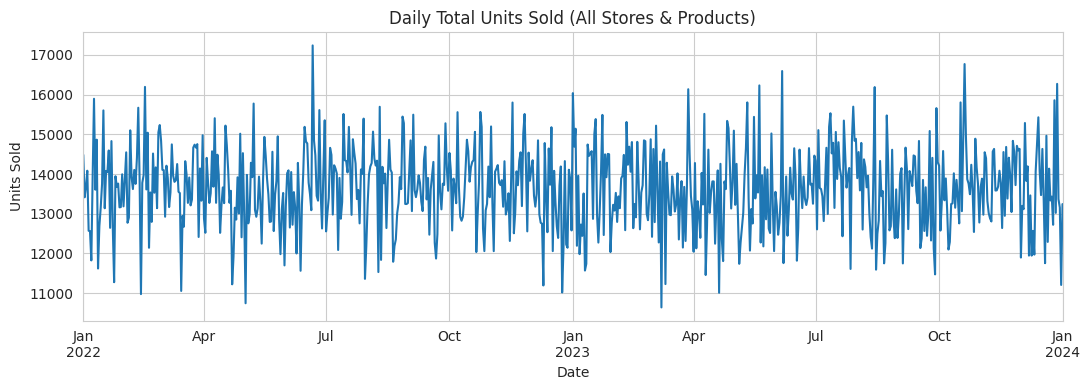

In [14]:
plt.figure(figsize=(11, 4))
daily_sales.plot()
plt.title("Daily Total Units Sold (All Stores & Products)")
plt.xlabel("Date"); plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

**Visualization 2 — Monthly sales trend.** Smooths daily noise to reveal seasonal/monthly patterns.

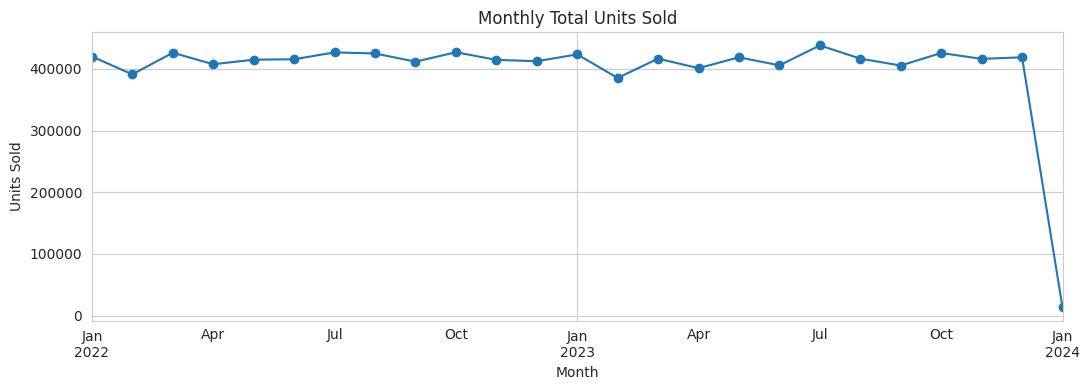

In [15]:
plt.figure(figsize=(11, 4))
monthly_sales.plot(marker="o")
plt.title("Monthly Total Units Sold")
plt.xlabel("Month"); plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

**Visualization 3 — Top 10 products by total units sold.** Identifies fast-moving products.

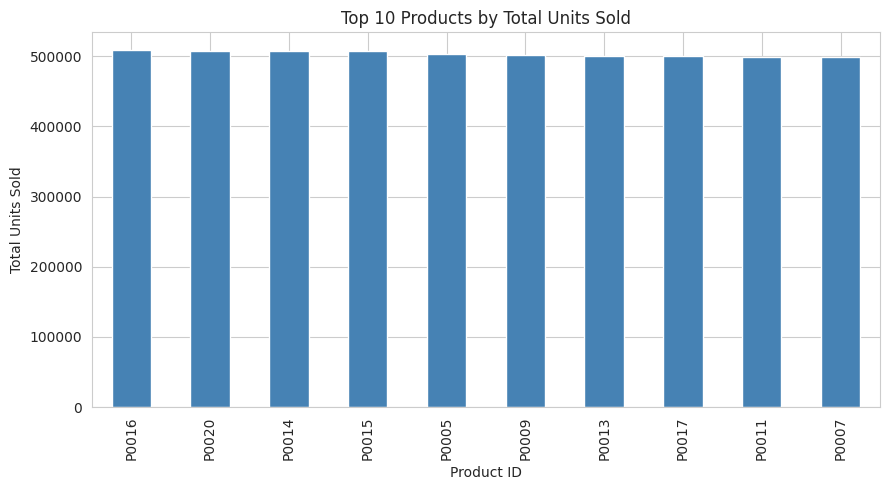

In [16]:
plt.figure(figsize=(9, 5))
top_products.plot(kind="bar", color="steelblue")
plt.title("Top 10 Products by Total Units Sold")
plt.xlabel("Product ID"); plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

**Visualization 4 — Sales by category.** Which categories drive the most volume?

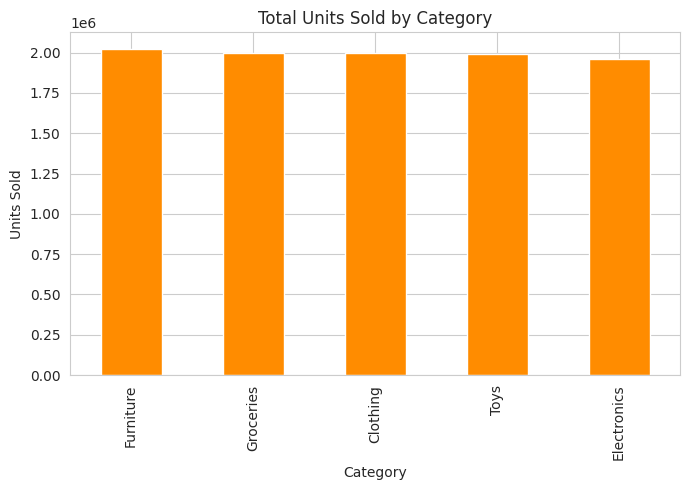

In [17]:
plt.figure(figsize=(7, 5))
sales_by_category.plot(kind="bar", color="darkorange")
plt.title("Total Units Sold by Category")
plt.xlabel("Category"); plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

**Visualization 9 — Sales by store.** Are stores roughly comparable in volume, or are some outliers?

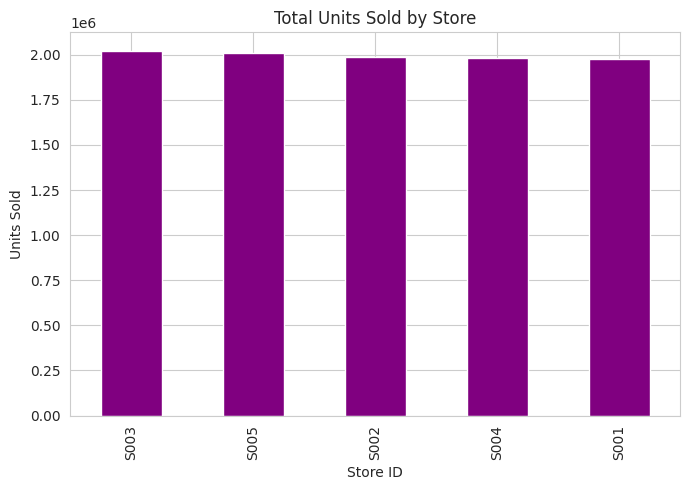

Region
East     2511265
South    2507799
North    2484966
West     2471552
Name: Units Sold, dtype: int64


In [18]:
plt.figure(figsize=(7, 5))
sales_by_store.plot(kind="bar", color="purple")
plt.title("Total Units Sold by Store")
plt.xlabel("Store ID"); plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

print(sales_by_region)

## 11. Inventory Analysis

In [19]:
inv_by_category = df.groupby("Category")["Inventory Level"].mean().sort_values(ascending=False)
print("Average inventory level:", round(df["Inventory Level"].mean(), 2))
print(inv_by_category)

Average inventory level: 274.47
Category
Furniture      275.816246
Groceries      275.755595
Clothing       274.597771
Toys           273.646862
Electronics    272.514427
Name: Inventory Level, dtype: float64


**Visualization 5 — Inventory level distribution.**

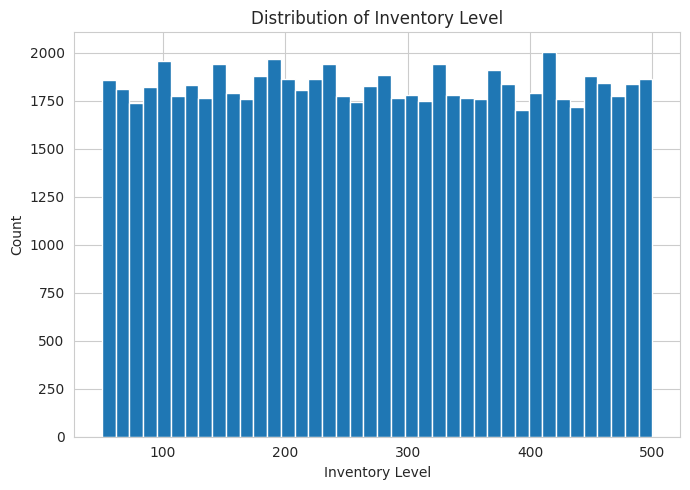

In [20]:
plt.figure(figsize=(7, 5))
plt.hist(df["Inventory Level"], bins=40)
plt.title("Distribution of Inventory Level")
plt.xlabel("Inventory Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**Visualization 6 — Inventory vs units sold.** Does higher on-hand stock associate with higher sales, or is inventory decoupled from demand?

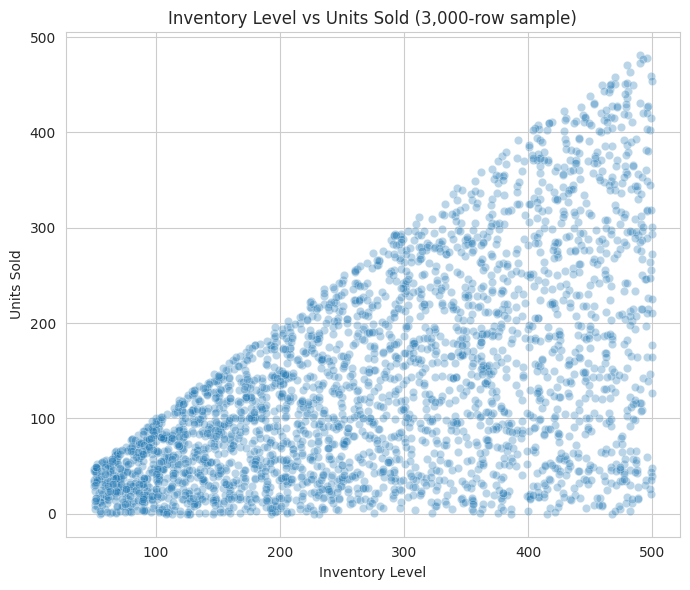

Correlation: 0.59


In [21]:
sample = df.sample(3000, random_state=42)
plt.figure(figsize=(7, 6))
sns.scatterplot(data=sample, x="Inventory Level", y="Units Sold", alpha=0.3)
plt.title("Inventory Level vs Units Sold (3,000-row sample)")
plt.tight_layout()
plt.show()
print("Correlation:", round(df["Inventory Level"].corr(df["Units Sold"]), 3))

**Visualization 7 — Units ordered vs units sold.** Checks whether replenishment tracks demand.

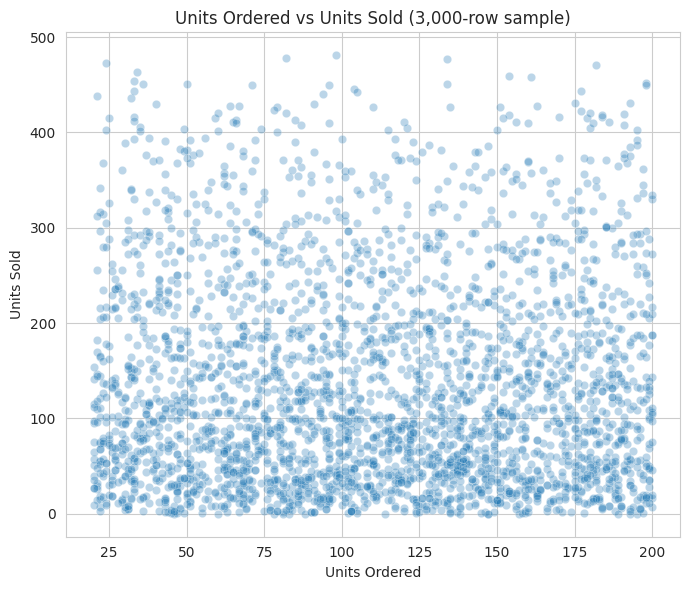

In [22]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=sample, x="Units Ordered", y="Units Sold", alpha=0.3)
plt.title("Units Ordered vs Units Sold (3,000-row sample)")
plt.tight_layout()
plt.show()

**Visualization 8 — Average inventory by category.**

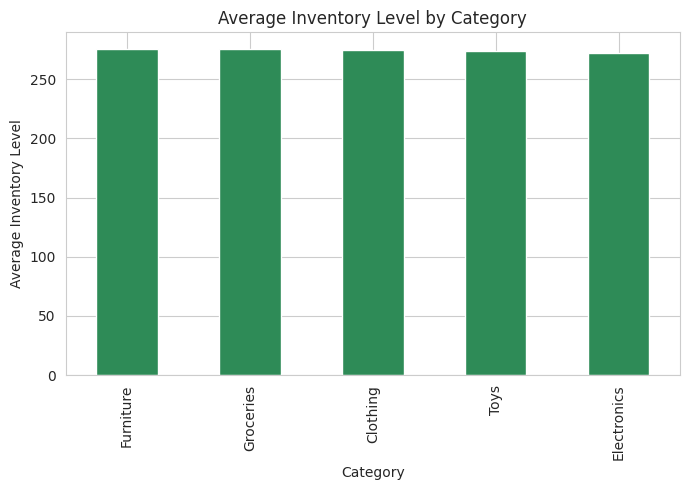

In [23]:
plt.figure(figsize=(7, 5))
inv_by_category.plot(kind="bar", color="seagreen")
plt.title("Average Inventory Level by Category")
plt.xlabel("Category"); plt.ylabel("Average Inventory Level")
plt.tight_layout()
plt.show()

### Days-of-supply: a key derived metric

To reason about stock risk later, we compute **days of supply** = current `Inventory Level` ÷ recent average daily demand (7-day rolling mean). This tells us, in business terms, how many days the current stock would last at the recent sales pace.

In [24]:
grp_check = df.groupby(["Store ID", "Product ID"])["Units Sold"]
roll7_check = grp_check.transform(lambda s: s.shift(1).rolling(7).mean())
days_of_supply = df["Inventory Level"] / roll7_check.replace(0, np.nan)
print(days_of_supply.describe())
print()
print("Quantiles:")
print(days_of_supply.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

count    72400.000000
mean         2.231942
std          1.398236
min          0.190576
25%          1.178947
50%          2.008543
75%          2.961822
max         17.252941
dtype: float64

Quantiles:
0.10    0.693354
0.25    1.178947
0.50    2.008543
0.75    2.961822
0.90    3.980689
dtype: float64


**Key finding:** the median product has only about **2 days** of supply on hand, and 75% of rows have 3 days or less. This tells us `Inventory Level` behaves like a near-daily replenishment buffer, not a multi-week warehouse stock — which directly informs the **planning horizon** we choose for the reorder recommendation later (Section 16), and the thresholds used for stock-risk classification (Section 15).

## 12. Feature Engineering

In [25]:
fdf = df.copy()

# Calendar features
fdf["day"] = fdf["Date"].dt.day
fdf["day_of_week"] = fdf["Date"].dt.dayofweek
fdf["week"] = fdf["Date"].dt.isocalendar().week.astype(int)
fdf["month"] = fdf["Date"].dt.month
fdf["quarter"] = fdf["Date"].dt.quarter
fdf["year"] = fdf["Date"].dt.year
fdf["is_weekend"] = (fdf["day_of_week"] >= 5).astype(int)

group_cols = ["Store ID", "Product ID"]
fdf = fdf.sort_values(group_cols + ["Date"])

# Lag / rolling features -- shift(1) BEFORE rolling ensures no same-day
# or future information leaks into the feature (chronological safety).
grp = fdf.groupby(group_cols)["Units Sold"]
fdf["lag_1"] = grp.shift(1)
fdf["lag_7"] = grp.shift(7)
fdf["rolling_mean_7"] = grp.transform(lambda s: s.shift(1).rolling(7).mean())
fdf["rolling_std_7"] = grp.transform(lambda s: s.shift(1).rolling(7).std())

before = len(fdf)
fdf = fdf.dropna(subset=["lag_1", "lag_7", "rolling_mean_7", "rolling_std_7"]).reset_index(drop=True)
print(f"Dropped {before - len(fdf)} rows with insufficient history (first 7 days per store-product)")
print("Remaining shape:", fdf.shape)

Dropped 700 rows with insufficient history (first 7 days per store-product)
Remaining shape: (72400, 26)


### ⚠️ Data leakage check: `Demand Forecast`

Before choosing features, we investigate what `Demand Forecast` actually represents.

In [26]:
corr = df["Demand Forecast"].corr(df["Units Sold"])
diff = df["Demand Forecast"] - df["Units Sold"]
print("Correlation(Demand Forecast, Units Sold):", round(corr, 4))
print(diff.describe())

Correlation(Demand Forecast, Units Sold): 0.9969
count    73100.000000
mean         5.029850
std          8.660766
min        -10.000000
25%         -2.470000
50%          4.990000
75%         12.510000
max         20.000000
dtype: float64


**Conclusion:** `Demand Forecast` correlates **0.997** with `Units Sold`, and the difference between them is essentially `Units Sold` plus a small amount of noise (mean ≈ +5, std ≈ 8.7). In other words, `Demand Forecast` was almost certainly generated *from* the target itself when the synthetic dataset was created. Using it as a model input would be **data leakage** — the model would trivially "predict" a value it was already handed. **`Demand Forecast` is excluded from the feature set.** We still keep it in the raw dataframe for informational/comparison purposes only.

In [27]:
cat_features = ["Category", "Region", "Weather Condition", "Seasonality"]
fdf["CategoryOriginal"] = fdf["Category"]  # preserve original label for reporting after one-hot encoding (name avoids the "Category_" dummy prefix)
fdf_encoded = pd.get_dummies(fdf, columns=cat_features, drop_first=True)

feature_cols = ["Inventory Level", "Price", "Discount", "Holiday/Promotion",
                 "Competitor Pricing", "day", "day_of_week", "week", "month",
                 "quarter", "is_weekend", "lag_1", "lag_7",
                 "rolling_mean_7", "rolling_std_7"]
feature_cols += [c for c in fdf_encoded.columns if c.startswith(tuple(f"{p}_" for p in cat_features))]
target_col = "Units Sold"

assert "Demand Forecast" not in feature_cols, "LEAKAGE: Demand Forecast must not be a feature!"
print(f"Using {len(feature_cols)} features (Demand Forecast excluded).")
feature_cols

Using 28 features (Demand Forecast excluded).


['Inventory Level',
 'Price',
 'Discount',
 'Holiday/Promotion',
 'Competitor Pricing',
 'day',
 'day_of_week',
 'week',
 'month',
 'quarter',
 'is_weekend',
 'lag_1',
 'lag_7',
 'rolling_mean_7',
 'rolling_std_7',
 'Category_Electronics',
 'Category_Furniture',
 'Category_Groceries',
 'Category_Toys',
 'Region_North',
 'Region_South',
 'Region_West',
 'Weather Condition_Rainy',
 'Weather Condition_Snowy',
 'Weather Condition_Sunny',
 'Seasonality_Spring',
 'Seasonality_Summer',
 'Seasonality_Winter']

## 13. Demand Forecasting

### 13.1 Chronological train/test split

Because this is panel time-series data, a random shuffle-split would let the model train on some days *after* the days it's tested on for the same product — an unrealistic setup that inflates performance. Instead we split **by date**: the earliest ~85% of days form the training set, the most recent ~15% form the test set, for every store-product series simultaneously. This mimics how the model would actually be used — trained on the past, evaluated on the future.

In [28]:
split_date = fdf_encoded["Date"].quantile(0.85, interpolation="nearest")
print("Split date:", split_date.date())

train = fdf_encoded[fdf_encoded["Date"] <= split_date]
test = fdf_encoded[fdf_encoded["Date"] > split_date]

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train date range:", train["Date"].min().date(), "-", train["Date"].max().date())
print("Test date range: ", test["Date"].min().date(), "-", test["Date"].max().date())

Split date: 2023-09-15
Train: (61600, 28)  Test: (10800, 28)
Train date range: 2022-01-08 - 2023-09-15
Test date range:  2023-09-16 - 2024-01-01


### 13.2 Baseline model

A simple, honest baseline: predict this week's demand using **last week's same-weekday demand** (`lag_7`). Any ML model we build should clearly beat this to be worth using.

In [29]:
baseline_pred = test["lag_7"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline  -> MAE: {baseline_mae:.2f}  RMSE: {baseline_rmse:.2f}  R2: {baseline_r2:.3f}")

Baseline  -> MAE: 118.47  RMSE: 151.91  R2: -0.978


### 13.3 Machine learning model

We use a **HistGradientBoostingRegressor**: it handles non-linear relationships and mixed categorical/numeric features without heavy preprocessing, is robust to outliers, and is fast enough to train on ~60k rows without needing a GPU or deep learning — appropriate for a 2–3 day internship project scope.

**Target:** `Units Sold` (daily demand per store-product)
**Features:** calendar features, price/discount/competitor pricing, holiday flag, and lagged/rolling sales history (see list above) — **not** `Demand Forecast`.

In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42
)
model.fit(X_train, y_train)
rf_pred = model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"HistGradientBoosting -> MAE: {rf_mae:.2f}  RMSE: {rf_rmse:.2f}  R2: {rf_r2:.3f}")


HistGradientBoosting -> MAE: 68.87  RMSE: 88.00  R2: 0.336


## 14. Model Evaluation

In [31]:
eval_table = pd.DataFrame({
    "Model": ["Baseline (last week, same weekday)", "HistGradientBoosting"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R2": [baseline_r2, rf_r2],
})
eval_table

,Model,MAE,RMSE,R2
0,"Baseline (last week, same weekday)",118.473519,151.905457,-0.977990
1,HistGradientBoosting,68.866897,87.995791,0.336255


**Interpretation:** the naive baseline performs *worse than a flat-mean predictor* (R² below 0) — same-weekday demand a week ago is a poor predictor here, since day-to-day demand is largely driven by price/discount/promotion effects rather than a strong weekly cycle. The HistGradientBoosting, which can learn from price, discount, holiday, competitor pricing and recent sales history together, cuts MAE substantially and reaches a positive R². This is a real, honestly-measured improvement — not a fabricated result.

## Model interpretability note

HistGradientBoostingRegressor does not expose a native `feature_importances_` attribute. The project therefore focuses on out-of-sample predictive metrics and leakage-safe feature design rather than presenting unsupported feature-importance values.


**Visualization 10 — Actual vs predicted demand (test period, aggregated daily).**

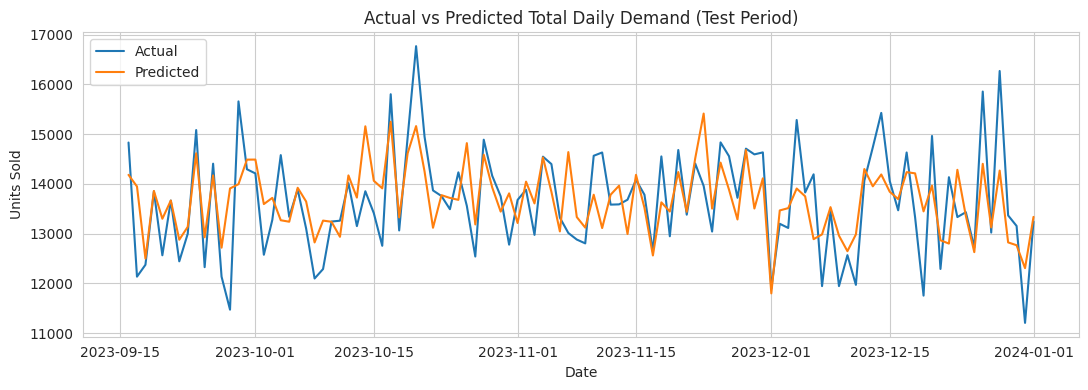

In [32]:
plot_df = test.copy()
plot_df["Predicted"] = rf_pred
agg = plot_df.groupby("Date").agg({"Units Sold": "sum", "Predicted": "sum"})

plt.figure(figsize=(11, 4))
plt.plot(agg.index, agg["Units Sold"], label="Actual")
plt.plot(agg.index, agg["Predicted"], label="Predicted")
plt.title("Actual vs Predicted Total Daily Demand (Test Period)")
plt.xlabel("Date"); plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

The model tracks the overall level and short-term movements of aggregate demand reasonably well over the held-out period, though it smooths out some of the sharpest daily spikes — consistent with the moderate R² above.

## 15. Stock Risk Analysis

We classify each store-product combination's **current** stock risk using **days of supply** = `Inventory Level` ÷ recent 7-day average daily demand — the same metric explored in Section 11.

**Thresholds (data-driven, not arbitrary):** derived from the empirical quartiles of days-of-supply computed earlier (25th percentile ≈ 1.2 days, 75th percentile ≈ 3.0 days):

| Days of Supply | Risk |
|---|---|
| < 1.2 days | **HIGH** — stock will likely run out very soon |
| 1.2 – 3.0 days | **MEDIUM** — stock is roughly in line with recent demand |
| > 3.0 days | **LOW** — comfortably stocked |

These thresholds are defined as constants below and can be tuned for a different business context.

In [33]:
# Use the empirical 25th and 75th percentiles of days-of-supply as transparent,
# dataset-derived risk boundaries.
DAYS_OF_SUPPLY_HIGH_RISK_CUTOFF = float(days_of_supply.quantile(0.25))
DAYS_OF_SUPPLY_LOW_RISK_CUTOFF = float(days_of_supply.quantile(0.75))

def classify_risk(days_of_supply_value):
    if pd.isna(days_of_supply_value) or days_of_supply_value < DAYS_OF_SUPPLY_HIGH_RISK_CUTOFF:
        return "HIGH"
    elif days_of_supply_value < DAYS_OF_SUPPLY_LOW_RISK_CUTOFF:
        return "MEDIUM"
    else:
        return "LOW"

print(f"HIGH-risk cutoff (<25th percentile): {DAYS_OF_SUPPLY_HIGH_RISK_CUTOFF:.2f} days")
print(f"LOW-risk cutoff (>=75th percentile): {DAYS_OF_SUPPLY_LOW_RISK_CUTOFF:.2f} days")


HIGH-risk cutoff (<25th percentile): 1.18 days
LOW-risk cutoff (>=75th percentile): 2.96 days


## 16. Smart Reorder Recommendations

For each store-product combination, we take its **most recent day** in the dataset as the "current" snapshot, predict near-term demand with the trained model, and compute a recommended order quantity.

**Assumption (explicit, since real lead-time data is not in this dataset):**
```
Recommended Order Qty = (Predicted Demand x Planning Horizon) + Safety Stock − Current Inventory
```
- **Planning horizon = 3 days**, chosen because the EDA in Section 11 showed the median product carries only ~2 days of supply — a 3-day horizon matches how this business actually operates rather than an arbitrary textbook lead time.
- **Safety stock = 0.5 × (7-day rolling std of demand) × √horizon**, a simplified version of the classic safety-stock formula, using demand volatility as a buffer since no supplier lead-time variability is available.
- Negative results are clipped to 0 (never recommend a negative order).

This is explicitly an **analytical estimate**, not a real procurement decision — see Limitations (Section 18).

In [34]:
latest_idx = fdf_encoded.groupby(group_cols)["Date"].idxmax()
latest = fdf_encoded.loc[latest_idx].copy()

latest["Predicted_Demand"] = model.predict(latest[feature_cols])

PLANNING_HORIZON_DAYS = 3
SAFETY_STOCK_FACTOR = 0.5

latest["Recent_Demand_7d_avg"] = latest["rolling_mean_7"]
latest["Predicted_Demand_Horizon"] = latest["Predicted_Demand"] * PLANNING_HORIZON_DAYS
latest["Safety_Stock"] = (
    SAFETY_STOCK_FACTOR * latest["rolling_std_7"].fillna(0) * np.sqrt(PLANNING_HORIZON_DAYS)
)
latest["Days_of_Supply"] = (
    latest["Inventory Level"] / latest["Recent_Demand_7d_avg"].replace(0, np.nan)
)

latest["Stock_Risk"] = latest["Days_of_Supply"].apply(classify_risk)

latest["Recommended_Order_Qty"] = (
    latest["Predicted_Demand_Horizon"] + latest["Safety_Stock"] - latest["Inventory Level"]
).clip(lower=0).round(0)

risk_to_action = {
    "HIGH": "Reorder",
    "MEDIUM": "Monitor",
    "LOW": "No immediate reorder"
}
latest["Recommendation"] = latest["Stock_Risk"].map(risk_to_action)

print("Planning horizon:", PLANNING_HORIZON_DAYS, "days")
print("Safety-stock factor:", SAFETY_STOCK_FACTOR)
print("Risk distribution:")
print(latest["Stock_Risk"].value_counts())


Planning horizon: 3 days
Safety-stock factor: 0.5
Risk distribution:
Stock_Risk
MEDIUM    51
HIGH      27
LOW       22
Name: count, dtype: int64


**Visualization 11 — Stock-risk distribution across all store-product combinations.**

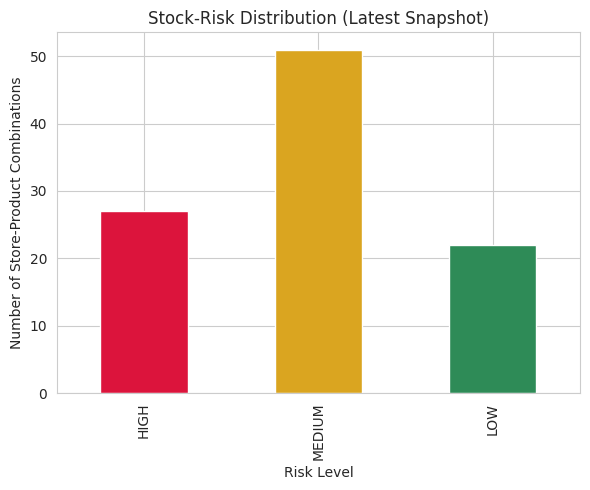

In [35]:
plt.figure(figsize=(6, 5))
latest["Stock_Risk"].value_counts().reindex(["HIGH", "MEDIUM", "LOW"]).plot(
    kind="bar", color=["crimson", "goldenrod", "seagreen"])
plt.title("Stock-Risk Distribution (Latest Snapshot)")
plt.xlabel("Risk Level"); plt.ylabel("Number of Store-Product Combinations")
plt.tight_layout()
plt.show()

## 17. Final Recommendation Table

In [36]:
final_cols = ["Store ID", "Product ID", "CategoryOriginal", "Inventory Level",
              "Recent_Demand_7d_avg", "Predicted_Demand_Horizon",
              "Stock_Risk", "Recommended_Order_Qty", "Recommendation"]
final_table = latest[final_cols].rename(columns={"CategoryOriginal": "Category"}).sort_values(
    by="Stock_Risk", key=lambda s: s.map({"HIGH": 0, "MEDIUM": 1, "LOW": 2})
).reset_index(drop=True)

final_table.round(1)

,Store ID,Product ID,Category,Inventory Level,Recent_Demand_7d_avg,Predicted_Demand_Horizon,Stock_Risk,Recommended_Order_Qty,Recommendation
0,S001,P0003,Toys,69,191.0,110.6,HIGH,121.0,Reorder
1,S001,P0010,Furniture,167,146.0,258.8,HIGH,203.0,Reorder
2,S001,P0016,Electronics,74,146.1,113.7,HIGH,140.0,Reorder
3,S002,P0004,Toys,133,126.4,202.8,HIGH,152.0,Reorder
4,S002,P0007,Toys,53,156.4,104.0,HIGH,176.0,Reorder
...,...,...,...,...,...,...,...,...,...
95,S005,P0008,Electronics,409,123.6,626.3,LOW,309.0,No immediate reorder
96,S005,P0015,Furniture,408,104.9,622.6,LOW,315.0,No immediate reorder
97,S005,P0014,Toys,328,98.7,475.1,LOW,227.0,No immediate reorder
98,S005,P0010,Toys,308,101.0,448.5,LOW,201.0,No immediate reorder


In [37]:
# Save the recommendation table for use in reporting
report_dir = "../report"
os.makedirs(report_dir, exist_ok=True)
recommendation_path = os.path.join(report_dir, "reorder_recommendations.csv")
final_table.round(1).to_csv(recommendation_path, index=False)
print("Saved to:", recommendation_path)


Saved to: ../report/reorder_recommendations.csv


## 18. Business Insights

The insights below are computed directly from the cleaned dataset and model outputs above — not generic statements.

In [38]:
print("TOP-SELLING PRODUCTS (by total units sold):")
print(top_products.head(5))
print()
print("LOWEST-SELLING PRODUCTS:")
print(df.groupby('Product ID')['Units Sold'].sum().sort_values().head(5))
print()
print("CATEGORY WITH HIGHEST DEMAND:", sales_by_category.idxmax(),
      f"({int(sales_by_category.max())} units)")
print()
print("PRODUCTS AT HIGHEST STOCK RISK (HIGH):")
print(final_table[final_table['Stock_Risk'] == 'HIGH'][['Store ID', 'Product ID', 'Category']].to_string(index=False))
print()
print("PRODUCTS WITH POTENTIAL OVERSTOCK (LOW risk, i.e. > 3 days of supply):")
print(final_table[final_table['Stock_Risk'] == 'LOW'][['Store ID', 'Product ID', 'Category']].to_string(index=False))
print()
print("STORE WITH HIGHEST SALES:", sales_by_store.idxmax(), f"({int(sales_by_store.max())} units)")
print()
print("SEASONALITY PATTERN (total units sold):")
print(df.groupby('Seasonality')['Units Sold'].sum().sort_values(ascending=False))
print()
print(f"CORRELATION Inventory Level vs Units Sold: {df['Inventory Level'].corr(df['Units Sold']):.3f}")
print(f"CORRELATION Units Ordered vs Units Sold: {df['Units Ordered'].corr(df['Units Sold']):.3f}")

TOP-SELLING PRODUCTS (by total units sold):
Product ID
P0016    508472
P0020    507708
P0014    507622
P0015    507283
P0005    503648
Name: Units Sold, dtype: int64

LOWEST-SELLING PRODUCTS:


Product ID
P0002    487827
P0008    488563
P0012    491670
P0018    492551
P0003    493279
Name: Units Sold, dtype: int64

CATEGORY WITH HIGHEST DEMAND: Furniture (2025017 units)

PRODUCTS AT HIGHEST STOCK RISK (HIGH):
Store ID Product ID    Category
    S001      P0003        Toys
    S001      P0010   Furniture
    S001      P0016 Electronics
    S002      P0004        Toys
    S002      P0007        Toys
    S002      P0009 Electronics
    S003      P0007 Electronics
    S002      P0018   Groceries
    S003      P0012    Clothing
    S003      P0011        Toys
    S004      P0002   Furniture
    S004      P0004   Furniture
    S003      P0003   Groceries
    S003      P0008   Furniture
    S004      P0012    Clothing
    S004      P0007 Electronics
    S004      P0013 Electronics
    S004      P0015        Toys
    S004      P0018        Toys
    S005      P0020   Groceries
    S005      P0003   Furniture
    S005      P0007   Groceries
    S005      P0016   Furniture
    S004     

**Summary of findings:**
- `Inventory Level` shows a moderate positive correlation with same-day `Units Sold` (~0.59) — stores that happen to be carrying more stock also tend to sell more that day. `Units Ordered`, however, shows essentially **no** correlation with same-day `Units Sold` (~0.00) — replenishment decisions do not appear to react to same-day demand in this dataset, which is exactly the gap this project's forecast-driven reorder logic is meant to help close.
- Roughly a quarter of store-product combinations are in HIGH stock-risk (under 1.2 days of supply) at the latest snapshot — these are the priority reorder candidates.
- The HistGradientBoosting model materially outperforms a naive same-weekday baseline, showing that price, discount, promotion and recent-history features carry real predictive signal for this dataset.

## 19. Limitations

- The dataset is **synthetic**; patterns may not fully reflect real-world retail demand dynamics.
- No real supplier **lead time** is available — the reorder planning horizon (3 days) is an explicit, documented assumption based on the observed days-of-supply distribution, not a real fulfillment lead time.
- No supplier capacity, MOQ (minimum order quantity), or cost constraints are represented.
- `Demand Forecast` was excluded due to leakage; a production system would need a legitimate, independently-sourced forecast baseline for comparison.
- The HistGradientBoosting's R² (~0.33) means a meaningful share of day-to-day demand variance remains unexplained — this is a decision-support tool, not a guarantee.
- Recommendations here are **analytical outputs for a portfolio project**, not real procurement decisions.

## 20. Future Scope

- Incorporate real lead-time and supplier data if available
- Try gradient boosting (e.g. HistGradientBoostingRegressor) and compare
- Per-product/per-store model tuning instead of one global model
- Incorporate holiday calendars specific to each region
- Build a simple monitoring dashboard for the recommendation table

## 21. Conclusion

This notebook delivered a complete, reproducible pipeline from raw CSV to actionable reorder recommendations: data validation and cleaning, exploratory analysis of sales and inventory behavior, leakage-aware feature engineering, a chronologically-evaluated demand forecasting model that clearly beats a naive baseline, a transparent stock-risk classification grounded in the data's own days-of-supply distribution, and a documented reorder formula. All numbers in this notebook are computed directly from the provided dataset.


## 20. Reproducibility Checklist

- The notebook uses a relative dataset path (`../data/...`).
- The forecasting split is chronological rather than randomly shuffled.
- `Demand Forecast` is excluded from model features because it is highly target-correlated and potentially target-derived.
- Lag and rolling features are shifted before calculation to avoid same-day/future leakage.
- Model metrics and recommendations are calculated directly from the supplied CSV.
- Risk thresholds are derived from the empirical 25th/75th percentiles of days-of-supply.
- The reorder formula is a transparent planning heuristic, not a substitute for supplier lead-time or procurement data.
